In [70]:
from tqdm import tqdm

import numpy as np
import awkward as ak
import vector
vector.register_awkward()
import uproot

import mplhep as hep
hep.style.use('CMS')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [80]:
# ---------- CMS Style ----------
plt.style.use('default')
mpl.rcParams['font.size'] = 16
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.linewidth'] = 1.2
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.minor.size'] = 3
 

## Test the Root Files

Just to check if the PF and PUPPI collections are what we expect.

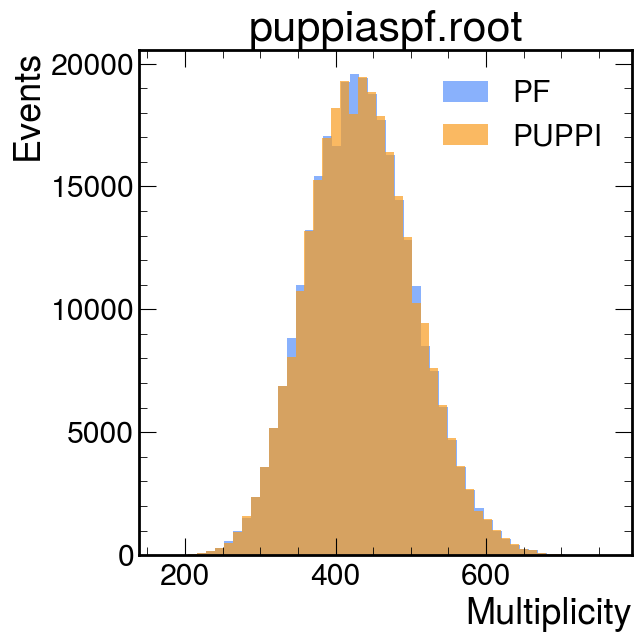

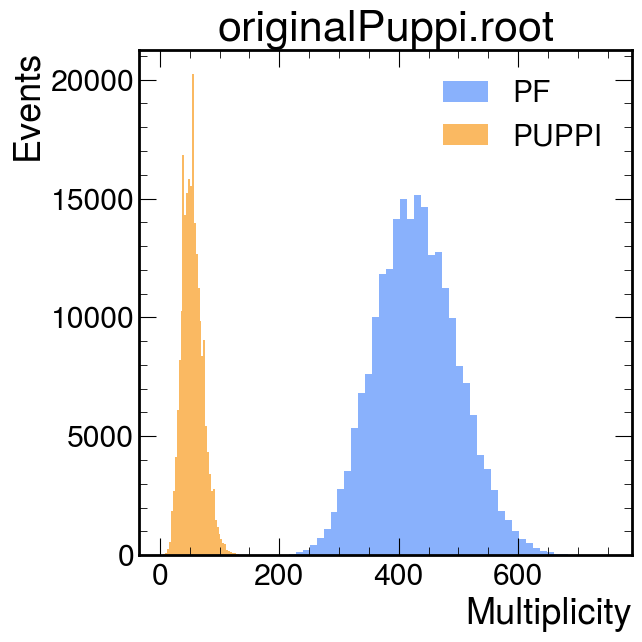

In [96]:

## Check that the files are produced correctly
file_pf_eq_puppi = "/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/perfNano_PU200.root"
#file_pf_eq_puppi = "/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/perfNano_PU140.root"
#file_pf_eq_puppi = "/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/perfNano_PU0.root"


file_puppi_subset_pf = "/eos/cms/store/group/cmst3/group/l1tr/kypark/BESTPUPPI/AR2025/TT_PU200/FP/perfNano.root"

# Open files and get multiplicities
f1 = uproot.open(file_pf_eq_puppi)["Events"]
f2 = uproot.open(file_puppi_subset_pf)["Events"]

n_pf_1 = f1["nL1PFCands"].array()
n_puppi_1 = f1["nL1PuppiCands"].array()

n_pf_2 = f2["nL1PFCands"].array()
n_puppi_2 = f2["nL1PuppiCands"].array()

# Plot multiplicities
plt.figure(figsize=(7,7))
plt.hist(n_pf_1, bins=50, alpha=0.7, label='PF')
plt.hist(n_puppi_1, bins=50, alpha=0.7, label='PUPPI')
plt.xlabel('Multiplicity')
plt.ylabel('Events')
plt.title('puppiaspf.root')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))



plt.hist(n_pf_2, bins=50, alpha=0.7, label='PF')
plt.hist(n_puppi_2, bins=50, alpha=0.7, label='PUPPI')
plt.xlabel('Multiplicity')
plt.ylabel('Events')
plt.title('originalPuppi.root')
plt.legend()

plt.tight_layout()
plt.show()

## Seeded Cone Python implementation

This is a “seeded cone” clustering algorithm, done event by event.
The particles argument should be an `Awkward` array of particles with `(pt, eta, phi)` fields
It returns a `Vector` of jets with fields `(pt, eta, phi)` and `constituents`. The `constituents` field are indices of the `particles` clustered to each jet.

In [97]:
## Creates 16 jets and only takes the first 12 (with higher pT)
def seeded_cone_exact(particles,
                       R: float = 0.4,
                       max_jets: int = 16, # Maximum number of jets based on PUPPI collection --> Make larger if larger PFCands collection
                       ) -> vector.Array:

    # --- Prepare per-particle kinematics
    pT = ak.fill_none(particles.pt, 0.0)
    eta = ak.fill_none(particles.eta, 0.0)
    phi = ak.fill_none(particles.phi, 0.0)

    out_jets = []
    n_events = len(particles)
    
    # --- Loop over events
    for ev in tqdm(range(n_events)):
        ev_pT = np.array(pT[ev].to_list())
        ev_eta = np.array(eta[ev].to_list())
        ev_phi = np.array(phi[ev].to_list())
        n = ev_pT.size
        # ...keeping track of clustered particles: remaining[i] includes particles not clustered into a jet yet.
        remaining = np.ones(n, dtype=bool)

        jets_ev = []

        # --- Loop over jets: build jets until you run out of particles or hit max_jets
        while remaining.any() and len(jets_ev) < max_jets:
            rem_indices = np.nonzero(remaining)[0]
            if rem_indices.size == 0:
                break
                
            # --- Define the seed as the highest pT remaining particle
            seed_idx = rem_indices[np.argmax(ev_pT[rem_indices])]

            # --- Find constituents within cone radius R around the seed: jet constituents are those within dR2 of the seed
            dr2 = (ev_eta[seed_idx] - ev_eta) ** 2 + (
                (ev_phi[seed_idx] - ev_phi + np.pi) % (2 * np.pi) - np.pi
            ) ** 2
            in_mask = (dr2 <= R * R) & remaining
            constituents = np.nonzero(in_mask)[0]

            # --- Compute jet axis as pT-weighted average: sum the pT and compute the (eta, phi) axis
            pT_cons = ev_pT[constituents]
            sum_pT = pT_cons.sum()
            if sum_pT <= 0:
                remaining[constituents] = False
                continue
            eta_jet = (pT_cons * ev_eta[constituents]).sum() / sum_pT
            cos_phi = (pT_cons * np.cos(ev_phi[constituents])).sum()
            sin_phi = (pT_cons * np.sin(ev_phi[constituents])).sum()
            phi_jet = np.arctan2(sin_phi, cos_phi)

            jets_ev.append({'pt'  : float(sum_pT),
                            'eta' : float(eta_jet),
                            'phi' : float(phi_jet),
                            'constituents' : constituents.tolist()})

            remaining[constituents] = False

        out_jets.append(jets_ev)
        
    jets_ak = ak.Array(out_jets)

    # --- Store the jet + list of constituent indices
    jets_vec = vector.zip({
        "pt": ak.values_astype(jets_ak["pt"], np.float64),
        "eta": ak.values_astype(jets_ak["eta"], np.float64),
        "phi": ak.values_astype(jets_ak["phi"], np.float64),
    })

    # Create a sorting index based on jet pT
    sort_indices = ak.argsort(jets_vec.pt, ascending=False)

    # Sort both the jets and the constituents using the same index
    sorted_jets = jets_vec[sort_indices]
    sorted_constituents = jets_ak["constituents"][sort_indices]

    # Take the top 12
    top_12_jets = sorted_jets[:, :12]
    top_12_constituents = sorted_constituents[:, :12]

    # Now, attach the constituents to the top 12 jets
    final_jets = ak.with_field(top_12_jets, top_12_constituents, "constituents")
    pt_mask = final_jets.pt > 5
    final_jets = final_jets[pt_mask]
    return final_jets

## Utilities for evaluating matching

The `match_jets` function matches jets between two collections event-by-event using closest ΔR.

It returns an Awkward array where each jet of `jets1` has fields:
- `j1` - the jet
- `j2` - the best matched jet from `jets2`
- `deltaR` - the dR between `j1` and `j2`
- `unmatched` - the properties of the jet if it doesn't have a good match

`compute_residuals` function returns the distance between these pairs in pT, eta, phi, and deltaR

In [98]:
def match_jets(jets1, jets2, dR_max=0.4):
    """
    Match jets2 to jets1 per event by closest ΔR.
    Returns an awkward array with fields: j1, j2, deltaR, unmatched
    """

    # --- Build all jet pairs within each event and compute ΔR for each pair using vector
    pairs = ak.cartesian({"j1": jets1, "j2": jets2}, axis=1, nested=True)
    dR = pairs["j1"].deltaR(pairs["j2"])

    best_idx = ak.argmin(dR, axis=-1, keepdims=True)

    matched_j2 = pairs["j2"][best_idx]
    matched_dR = dR[best_idx]

    mask = matched_dR < dR_max

    matched_j1   = ak.mask(jets1, mask)
    unmatched_j1 = ak.mask(jets1, ~mask)
    matched_j2   = ak.mask(matched_j2, mask)
    matched_dR   = ak.mask(matched_dR, mask)

    return ak.zip({
        "j1": matched_j1,
        "j2": matched_j2,
        "deltaR": matched_dR,
        "unmatched": unmatched_j1,
    })

In [99]:
def compute_residuals(matches):
    j1 = ak.drop_none(matches["j1"])
    j2 = ak.drop_none(matches["j2"])

    return {
        "pt": ak.to_numpy(ak.flatten((j1.pt - j2.pt) / j2.pt, axis=None)),
        "eta": ak.to_numpy(ak.flatten(j1.eta - j2.eta, axis=None)),
        "phi": ak.to_numpy(ak.flatten(j1.deltaphi(j2), axis=None)),
        "deltaR": ak.to_numpy(ak.flatten(j1.deltaR(j2), axis=None)),
    }

## Recluster Jets with original PUPPI collection

Using the original PUPPI collection from the file_puppi_subset_pf.root file, we recluster the jets and see the results comparing them to the scPuppiJets

In [100]:
# Number of events to process
N_sub = 50000  # change as needed

# Open an old file where PF != PUPPI collection
with uproot.open(file_puppi_subset_pf) as f:
    tree = f["Events"]

    # PUPPI candidates → input particles for reclustering (only first N_sub events)
    particles_sub = ak.zip({
        "pt":  tree["L1PuppiCands_pt"].array(entry_stop=N_sub),
        "eta": tree["L1PuppiCands_eta"].array(entry_stop=N_sub),
        "phi": tree["L1PuppiCands_phi"].array(entry_stop=N_sub),
    })

    # Reference jets from CMSSW (scPuppiJets), same event range
    ref_jets_sub = vector.zip({
        "pt":  tree["scPuppiJets_pt"].array(entry_stop=N_sub),
        "eta": tree["scPuppiJets_eta"].array(entry_stop=N_sub),
        "phi": tree["scPuppiJets_phi"].array(entry_stop=N_sub),
    })

    gen_jets_sub = vector.zip({
        "pt":  tree["GenJets_pt"].array(entry_stop=N_sub),
        "eta": tree["GenJets_eta"].array(entry_stop=N_sub),
        "phi": tree["GenJets_phi"].array(entry_stop=N_sub),
    })

    # Reclustering from PUPPI cands with seeded-cone implementation
    newJets_sub = seeded_cone_exact(particles_sub, R=0.4, max_jets=16)

# Match reclustered jets to scPuppiJets and compute residuals
matches_sub = match_jets(newJets_sub, ref_jets_sub, dR_max=0.4)
res_sub = compute_residuals(matches_sub)

100%|██████████| 50000/50000 [00:55<00:00, 908.53it/s] 


[]

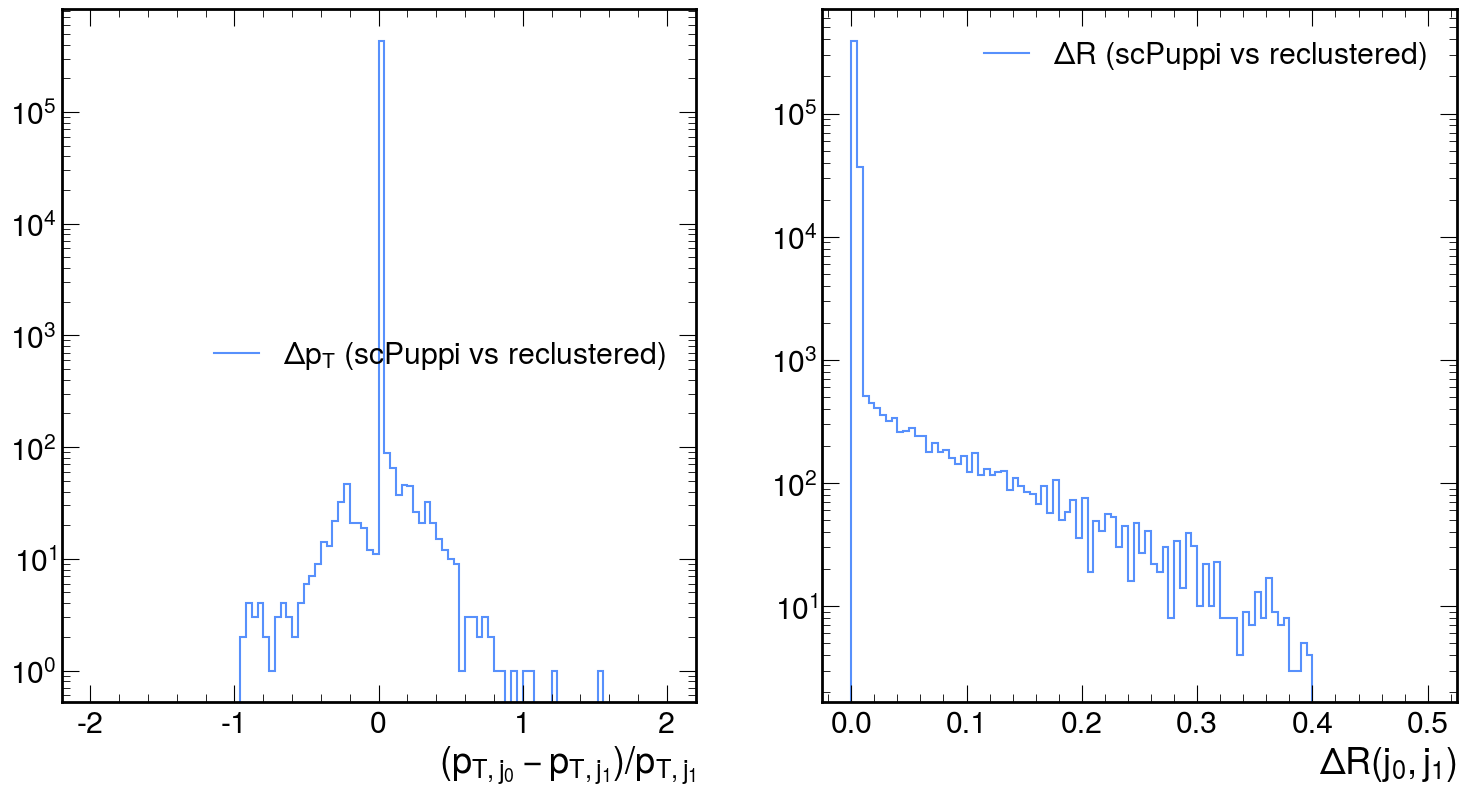

In [101]:
# Plot residuals in pT and plot ΔR between matched jets, to check the performance of the reclustering and the agreement with scPuppiJets

pt_bins = np.linspace(-2, 2, 101)
dR_bins = np.linspace(0, 0.5, 101)

f, axs = plt.subplots(1, 2, figsize=(18, 9))

h, _ = np.histogram(res_sub["pt"], bins=pt_bins)
hep.histplot(h, pt_bins, label=r"$\Delta p_T$ (scPuppi vs reclustered)", ax=axs[0])

h, _ = np.histogram(res_sub["deltaR"], bins=dR_bins)
hep.histplot(h, dR_bins, label=r"$\Delta R$ (scPuppi vs reclustered)", ax=axs[1])

axs[0].set_xlabel(r"$(p_{T, j_0} - p_{T, j_1}) / p_{T, j_1}$")
axs[1].set_xlabel(r"$\Delta R (j_0, j_1)$")
axs[0].legend()
axs[1].legend()
axs[0].semilogy()
axs[1].semilogy()

Number of matched jets: 436314


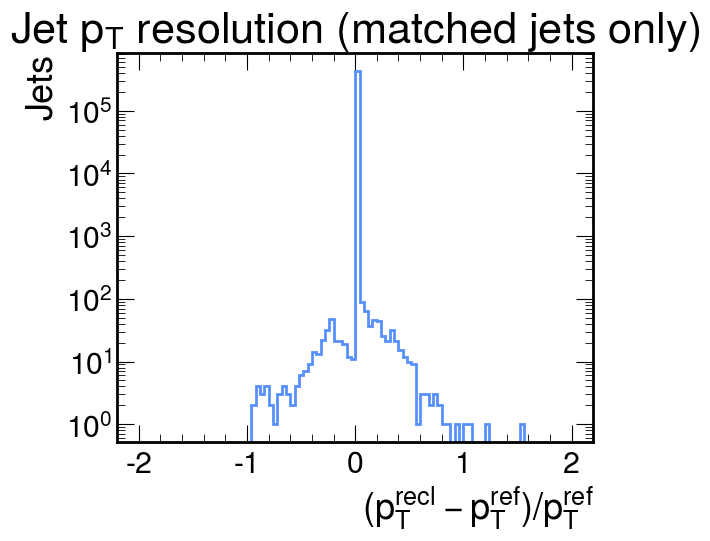

In [102]:
# Jet pT resolution for matched jets only
res_pt = res_sub["pt"]  # (pT_reclustered - pT_ref) / pT_ref

print("Number of matched jets:", len(res_pt))

bins = np.linspace(-2, 2, 101)

plt.figure(figsize=(7,6))
plt.hist(res_pt, bins=bins, histtype="step", linewidth=2)
plt.xlabel(r"$(p_T^\mathrm{recl} - p_T^\mathrm{ref}) / p_T^\mathrm{ref}$")
plt.ylabel("Jets")
plt.title("Jet $p_T$ resolution (matched jets only)")
plt.tight_layout()
plt.yscale("log")
plt.show()

Number of matched jets (new, ref): 436314 436314


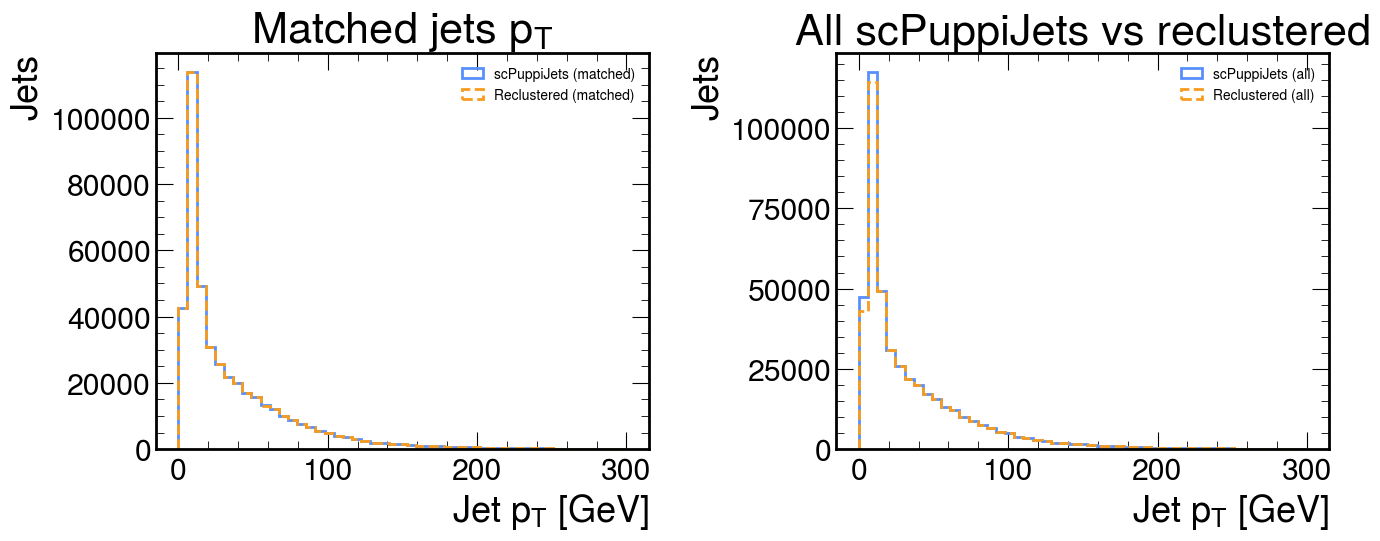

In [103]:
## Plot the jets pT

# Get matched jets
j1 = ak.drop_none(matches_sub["j1"])  # reclustered jets (matched)
j2 = ak.drop_none(matches_sub["j2"])  # reference scPuppiJets (matched)

pt_new_matched = ak.to_numpy(ak.flatten(j1.pt, axis=None))
pt_ref_matched = ak.to_numpy(ak.flatten(j2.pt, axis=None))

print("Number of matched jets (new, ref):", len(pt_new_matched), len(pt_ref_matched))

# All reference jets
pt_ref_all = ak.to_numpy(ak.flatten(ref_jets_sub.pt, axis=None))
pt_new_all = ak.to_numpy(ak.flatten(newJets_sub.pt, axis=None))


# --- pT ranges and bins ---
# Left panel (matched vs matched)
pt_min_match = min(pt_new_matched.min(), pt_ref_matched.min())
pt_max_match = max(pt_new_matched.max(), pt_ref_matched.max())
bins_match = np.linspace(0, 300, 50)

# Right panel (all ref vs matched new)
pt_min_all = min(pt_ref_all.min(), pt_new_matched.min())
pt_max_all = max(pt_ref_all.max(), pt_new_matched.max())
bins_all = np.linspace(0, 300, 50)

# --- Side-by-side plots ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: matched new vs matched ref
axs[0].hist(pt_ref_matched, bins=bins_match, histtype="step", linewidth=2,
            label="scPuppiJets (matched)")
axs[0].hist(pt_new_matched, bins=bins_match, histtype="step", linewidth=2, linestyle="--",
            label="Reclustered (matched)")
axs[0].set_xlabel(r"Jet $p_T$ [GeV]")
axs[0].set_ylabel("Jets")
axs[0].set_title("Matched jets $p_T$")
axs[0].legend(fontsize=10)

# Right: all ref vs matched new
axs[1].hist(pt_ref_all, bins=bins_all, histtype="step", linewidth=2,
            label="scPuppiJets (all)")
axs[1].hist(pt_new_all, bins=bins_all, histtype="step", linewidth=2, linestyle="--",
            label="Reclustered (all)")
axs[1].set_xlabel(r"Jet $p_T$ [GeV]")
axs[1].set_ylabel("Jets")
axs[1].set_title("All scPuppiJets vs reclustered")
axs[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

### Now compare the jets with GEN jets

In [104]:
# Match reclustered jets to GEN jets
matches_gen = match_jets(newJets_sub, gen_jets_sub, dR_max=0.4)
res_gen = compute_residuals(matches_gen)

print(f"Matched {len(res_gen['pt'])} reclustered jets to GEN jets")

# Match scPuppiJets to GEN jets
matches_scPuppi_gen = match_jets(ref_jets_sub, gen_jets_sub, dR_max=0.4)
res_scPuppi_gen = compute_residuals(matches_scPuppi_gen)

print(f"Matched {len(res_scPuppi_gen['pt'])} scPuppiJets to GEN jets")

# Define pT bins for analysis (same as used in reco vs ref comparison)
pt_bins = np.array([0, 20, 40, 60, 80, 100, 150, 200])
pt_bin_centers = 0.5 * (pt_bins[:-1] + pt_bins[1:])

# --- Apply eta cut ---
#eta_cut = 1.3
#matches_gen = matches_gen[abs(matches_gen.j2.eta) < eta_cut]
#matches_scPuppi_gen = matches_scPuppi_gen[abs(matches_scPuppi_gen.j2.eta) < eta_cut]


print(f"pT bins: {pt_bins}")
print(f"pT bin centers: {pt_bin_centers}")

Matched 286729 reclustered jets to GEN jets
Matched 287597 scPuppiJets to GEN jets
pT bins: [  0  20  40  60  80 100 150 200]
pT bin centers: [ 10.  30.  50.  70.  90. 125. 175.]


In [105]:
# --- Compute statistics for RECLUSTERED vs GEN ---

# Extract matched jets
j1_gen = ak.drop_none(matches_gen["j1"])  # reclustered jets
j2_gen = ak.drop_none(matches_gen["j2"])  # GEN jets

pt_gen = ak.to_numpy(ak.flatten(j2_gen.pt, axis=None))    # GEN jet pT (x-axis)
pt_reco = ak.to_numpy(ak.flatten(j1_gen.pt, axis=None))   # reclustered jet pT

# Compute resolution and response
response_ratio_gen = pt_reco / pt_gen                      # response

# Bin the data
bin_indices_gen = np.digitize(pt_gen, pt_bins) - 1

# Compute mean, RMS (std), and error on mean in each bin
median_response_gen = []
err_median_response_gen = []  # Error on the mean = std/sqrt(N)
std_reco = []  
pt_reco_median = []  # To store median RECLUSTERED pT in each bin for plotting

for i in range(len(pt_bins) - 1):
    mask = bin_indices_gen == i
    if not np.any(mask):
        median_response_gen.append(np.nan)
        err_median_response_gen.append(np.nan)
        std_reco.append(np.nan)
        pt_reco_median.append(np.nan)
        continue
    
    vals_resp = response_ratio_gen[mask]
    N = len(vals_resp)

    median_response_gen.append(np.median(vals_resp))
    std_resp = np.std(vals_resp)
    err_median_response_gen.append(std_resp / np.sqrt(N))  # Standard error of the mean
    std_reco.append(np.std(pt_reco[mask]))
    pt_reco_median.append(np.median(pt_reco[mask]))


median_response_gen = np.array(median_response_gen)
err_median_response_gen = np.array(err_median_response_gen)
std_reco = np.array(std_reco)
pt_reco_median = np.array(pt_reco_median)

print("Reclustered vs GEN statistics computed")

Reclustered vs GEN statistics computed


In [106]:
# --- Compute statistics for scPuppiJets vs GEN ---

# Extract matched jets
j1_scPuppi = ak.drop_none(matches_scPuppi_gen["j1"])  # scPuppiJets
j2_scPuppi = ak.drop_none(matches_scPuppi_gen["j2"])  # GEN jets

pt_gen_scPuppi = ak.to_numpy(ak.flatten(j2_scPuppi.pt, axis=None))      # GEN jet pT
pt_scPuppi = ak.to_numpy(ak.flatten(j1_scPuppi.pt, axis=None))          # scPuppi jet pT

# Compute resolution and response
response_ratio_scPuppi_gen = pt_scPuppi / pt_gen_scPuppi                # response

# Bin the data
bin_indices_scPuppi_gen = np.digitize(pt_gen_scPuppi, pt_bins) - 1

# Compute mean, RMS (std), and error on mean in each bin
median_response_scPuppi_gen = []
err_median_response_scPuppi_gen = []  # Error on the mean = std/sqrt(N)
std_reco_scPuppi = []
pt_reco_median_scPuppi = []  # To store median RECLUSTERED pT in each bin for plotting

for i in range(len(pt_bins) - 1):
    mask = bin_indices_scPuppi_gen == i
    if not np.any(mask):
        median_response_scPuppi_gen.append(np.nan)
        err_median_response_scPuppi_gen.append(np.nan)
        std_reco_scPuppi.append(np.nan)
        pt_reco_median_scPuppi.append(np.nan)
        continue
    
    vals_resp = response_ratio_scPuppi_gen[mask]
    N = len(vals_resp)
    

    median_response_scPuppi_gen.append(np.median(vals_resp))
    std_resp = np.std(vals_resp)
    err_median_response_scPuppi_gen.append(std_resp / np.sqrt(N))  # Standard error of the mean
    std_reco_scPuppi.append(np.std(pt_scPuppi[mask]))
    pt_reco_median_scPuppi.append(np.median(pt_scPuppi[mask]))


median_response_scPuppi_gen = np.array(median_response_scPuppi_gen)
err_median_response_scPuppi_gen = np.array(err_median_response_scPuppi_gen)
std_reco_scPuppi = np.array(std_reco_scPuppi)
pt_reco_median_scPuppi = np.array(pt_reco_median_scPuppi)
print("scPuppiJets vs GEN statistics computed")

scPuppiJets vs GEN statistics computed


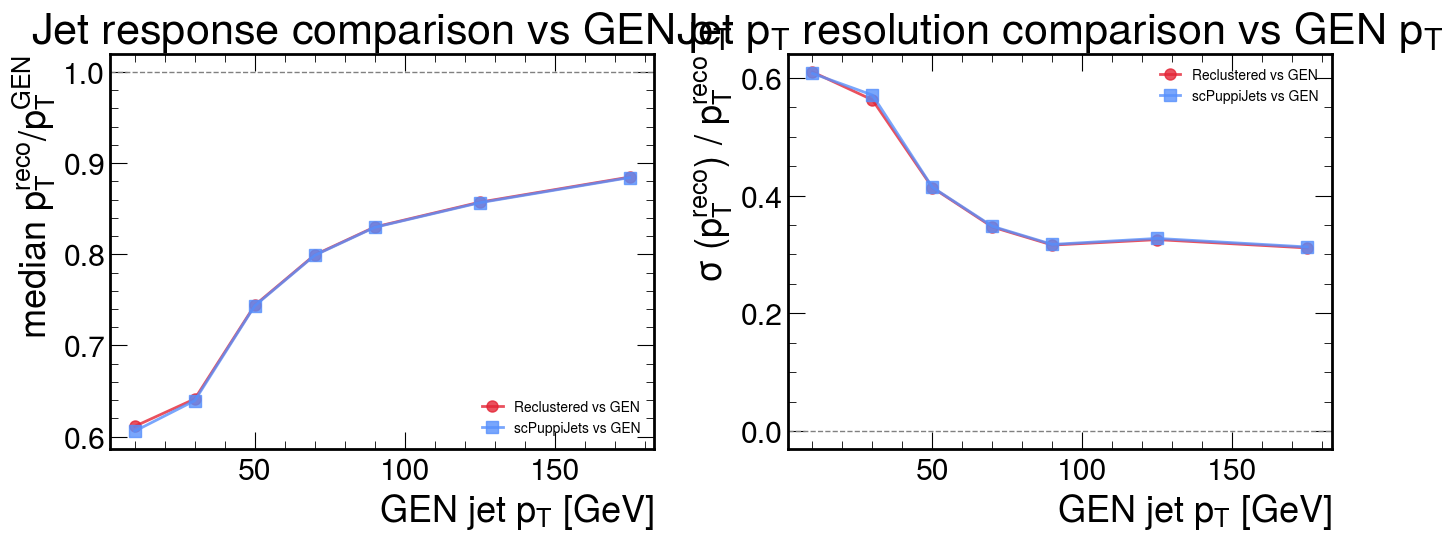

In [107]:
# --- Comparison: Reclustered vs scPuppiJets (both against GEN) ---

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: Response comparison (using error on the mean, not RMS!)
axs[0].plot(pt_bin_centers, median_response_gen, "o-", color="C2", linewidth=2, markersize=8,
            label="Reclustered vs GEN", alpha=0.8)
axs[0].plot(pt_bin_centers, median_response_scPuppi_gen, "s-", color="C0", linewidth=2, markersize=8,
            label="scPuppiJets vs GEN", alpha=0.8)
axs[0].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axs[0].set_xlabel(r"GEN jet $p_T$ [GeV]")
axs[0].set_ylabel(r"median $p_T^\mathrm{reco} / p_T^\mathrm{GEN}$")
axs[0].set_title("Jet response comparison vs GEN $p_T$")
axs[0].legend(fontsize=10)
#axs[0].grid(True, alpha=0.3)

# Right: Resolution σ comparison
axs[1].plot(pt_bin_centers, std_reco/pt_reco_median, "o-", color="C2", linewidth=2, markersize=8,
            label="Reclustered vs GEN", alpha=0.8)
axs[1].plot(pt_bin_centers, std_reco_scPuppi/pt_reco_median_scPuppi, "s-", color="C0", linewidth=2, markersize=8,
            label="scPuppiJets vs GEN", alpha=0.8)
axs[1].axhline(0.0, color="gray", linestyle="--", linewidth=1)
axs[1].set_xlabel(r"GEN jet $p_T$ [GeV]")
axs[1].set_ylabel(r"$\sigma$ ($p_T^\mathrm{reco}$) / $p_T^\mathrm{reco}$")
axs[1].set_title("Jet $p_T$ resolution comparison vs GEN $p_T$")
axs[1].legend(fontsize=10)
#axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Compute the PUPPI collections

Starting from the puppi_as_pf root file, let's compute two PUPPI collections:
- hand-made PUPPI collection --> using the original PUPPI weight
- new PUPPI collection --> using the new target

In [108]:
## Including fixes on the target from Elisa
file_path = file_pf_eq_puppi

file = uproot.open(file_path)
events = file["Events"]
print("Branches in 'Events':")
print(events.keys())
print(len(events))



Branches in 'Events':
['run', 'luminosityBlock', 'event', 'bunchCrossing', 'orbitNumber', 'nDecEmCaloBarrel', 'DecEmCaloBarrel_hwEta', 'DecEmCaloBarrel_hwPhi', 'DecEmCaloBarrel_hwQual', 'DecEmCaloBarrel_eta', 'DecEmCaloBarrel_phi', 'DecEmCaloBarrel_pt', 'nDecEmCaloHGCalNoTK', 'DecEmCaloHGCalNoTK_hwEta', 'DecEmCaloHGCalNoTK_hwPhi', 'DecEmCaloHGCalNoTK_hwQual', 'DecEmCaloHGCalNoTK_eta', 'DecEmCaloHGCalNoTK_phi', 'DecEmCaloHGCalNoTK_pt', 'nDecEmCaloHGCal', 'DecEmCaloHGCal_hwEta', 'DecEmCaloHGCal_hwPhi', 'DecEmCaloHGCal_hwQual', 'DecEmCaloHGCal_eta', 'DecEmCaloHGCal_phi', 'DecEmCaloHGCal_pt', 'nDecHadCaloBarrel', 'DecHadCaloBarrel_hwEta', 'DecHadCaloBarrel_hwPhi', 'DecHadCaloBarrel_hwQual', 'DecHadCaloBarrel_eta', 'DecHadCaloBarrel_phi', 'DecHadCaloBarrel_pt', 'nDecHadCaloHGCalNoTK', 'DecHadCaloHGCalNoTK_hwEta', 'DecHadCaloHGCalNoTK_hwPhi', 'DecHadCaloHGCalNoTK_hwQual', 'DecHadCaloHGCalNoTK_eta', 'DecHadCaloHGCalNoTK_phi', 'DecHadCaloHGCalNoTK_pt', 'nDecHadCaloHGCal', 'DecHadCaloHGCal_hwEt

In [109]:
## change these to correctly point to the branches of interest in the target ntuple

## all particles
target_numerator = "L1PuppiCands_genPtSum0p2"
target_denominator = "L1PuppiCands_recoDen_seedPlusAll0p2"


## charged
#target_numerator  = "L1PuppiCands_genChPlusMatchedNe0p2"
#target_denominator = "L1PuppiCands_recoDen_seedPlusCh0p2"

In [110]:
## get only a subset of events for testing
n_events_to_process = 50000

arrays = events.arrays(
    [
        "L1PuppiCands_pt",
        "L1PuppiCands_phi",
        "L1PuppiCands_eta",
        "L1PuppiCands_mass",
        "L1PuppiCands_puppiWeight",
        "L1PuppiCands_charge",
        "L1PuppiCands_nnVtxScore",
        "L1PuppiCands_pdgId",
        target_numerator,
        target_denominator,
        "GenJets_pt",
        "GenJets_eta",
        "GenJets_phi"
    ],
    entry_start=0,
    entry_stop=n_events_to_process,
    library="ak",   # <--- key change
)

pt     = arrays["L1PuppiCands_pt"]
phi    = arrays["L1PuppiCands_phi"]
eta    = arrays["L1PuppiCands_eta"]
mass   = arrays["L1PuppiCands_mass"]
weight = arrays["L1PuppiCands_puppiWeight"]
charge = arrays["L1PuppiCands_charge"]
nnVtxScore = arrays["L1PuppiCands_nnVtxScore"]
pdgid      = arrays["L1PuppiCands_pdgId"]

### Hand-made PUPPI collection
Starting from this pf_as_puppi root file, we can recreate an hand-made PUPPI collection. 
The PUPPI weight is the original one, and the new PUPPi collection is computed reweighting the pT of the neutral particles and applying the various cuts on pT and on NNVtx score (for charged)

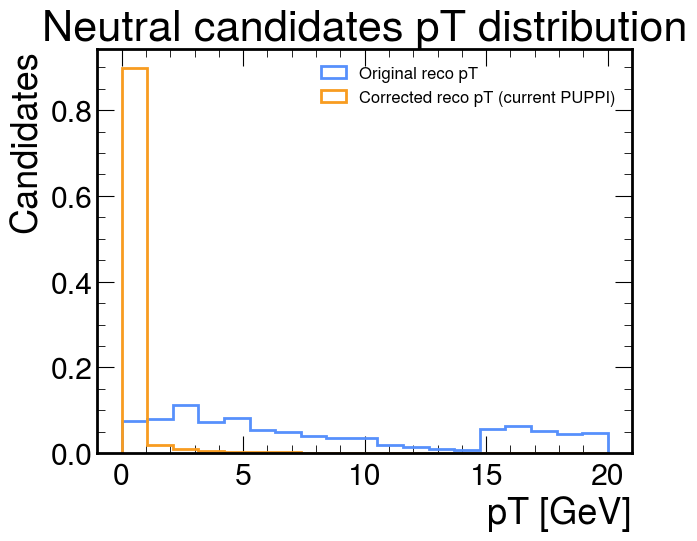

In [111]:
# Corrected reco pT`
akpt     = pt
akweight = weight
akcharge = charge

# --- SELECT ONLY NEUTRAL CANDIDATES ---
neutral_mask = (akcharge == 0)

pt_neutral     = akpt[neutral_mask]
weight_neutral = akweight[neutral_mask]

# Corrected pT (current PUPPI weight)
pt_corr_neutral = pt_neutral * weight_neutral

# --- SAFE FLATTENING ---
flat_pt = ak.flatten(pt_neutral, axis=None).to_numpy()
flat_pt_corr = ak.flatten(pt_corr_neutral, axis=None).to_numpy()

# Remove None/NaN
flat_pt = flat_pt[np.isfinite(flat_pt)]
flat_pt_corr = flat_pt_corr[np.isfinite(flat_pt_corr)]

# -------------------------------
#        Plot
# -------------------------------
plt.figure(figsize=(7,6))
bins = np.linspace(0, 20, 20)

plt.hist(flat_pt, bins=bins, histtype="step", linewidth=2, density=True,
         label="Original reco pT")
plt.hist(flat_pt_corr, bins=bins, histtype="step", linewidth=2, density=True,
         label="Corrected reco pT (current PUPPI)")

plt.xlabel(" pT [GeV]")
plt.ylabel("Candidates")
plt.title("Neutral candidates pT distribution")
plt.legend(loc="upper right", frameon=False, fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

In [112]:
# create the new branches for the hand-made PUPPI collection, which will be used later for the jet resolution

selected_counts = []
selected_pts = []     # list of lists
selected_etas = []
selected_phis = []
selected_masses = []
selected_effective_pts = []  # pt after weighting (for MET)

for iev in range(len(pt)):

    sel_pt = []
    sel_eta = []
    sel_phi = []
    sel_mass = []
    sel_effpt = []   # pt used in MET (pt*weight or pt)
    if iev % 5000 == 0:
        print(f"Processing event {iev}/{len(pt)}")
    for pt_i, weight_i, charge_i, nnVtxScore_i, eta_i, phi_i, mass_i, pdgid_i in zip(
            pt[iev], weight[iev], charge[iev], nnVtxScore[iev],
            eta[iev], phi[iev], mass[iev], pdgid[iev]):

        abs_eta = abs(eta_i)

        ###############
        # Barrel
        ###############

        if abs_eta < 1.5:
        
            if charge_i == 0:
                #print(f"Event {iev}: Neutral candidate with pt={pt_i}, eta = {eta_i}, reweighter pt = {pt_i * weight_i}, phi = {phi_i}, weight={weight_i}")
                if np.round((pt_i * weight_i) / 0.25) * 0.25 >= 1:
                    eff_pt = pt_i * weight_i
                    eff_pt = np.round(eff_pt / 0.25) * 0.25
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")

            if charge_i !=0:
                if nnVtxScore_i > 0.1:
                    eff_pt = pt_i
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)

        ###############
        # HGCAL with TK
        ###############
        if 1.5 < abs_eta < 2.5:

            if charge_i == 0:
                if abs_eta < 2.0:
                    pt_cut = 1.0
                else:
                    pt_cut = 2.0
                
                if np.round((pt_i * weight_i) / 0.25) * 0.25 >= pt_cut:
                    eff_pt = pt_i * weight_i
                    eff_pt = np.round(eff_pt / 0.25) * 0.25
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")

            if charge_i !=0:
                if nnVtxScore_i >= 0.1:
                    eff_pt = pt_i
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #if iev == 82:
                    #    print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")
        ###############
        # HGCAL no-TK
        ###############

        elif 2.5 < abs_eta < 3.0:
            continue  # your original code skipped them

        ###############
        # HF
        ###############
        elif 3.0 < abs_eta < 5.2:
            continue  # skipped in your code
    # store per-event results to compute the MET later

    selected_counts.append(len(sel_effpt))     # same as before, but using final selected
    selected_pts.append(sel_pt)
    selected_etas.append(sel_eta)
    selected_phis.append(sel_phi)
    selected_masses.append(sel_mass)
    selected_effective_pts.append(sel_effpt)

Processing event 0/50000
Processing event 5000/50000
Processing event 10000/50000
Processing event 15000/50000
Processing event 20000/50000
Processing event 25000/50000
Processing event 30000/50000
Processing event 35000/50000
Processing event 40000/50000
Processing event 45000/50000


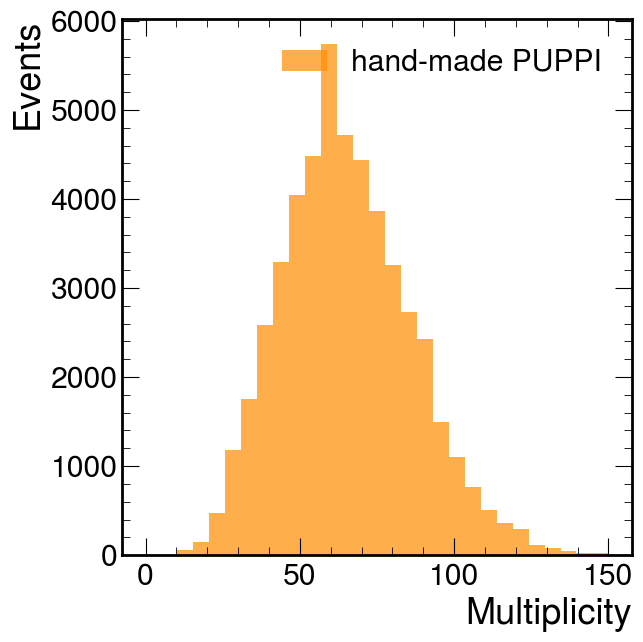

<Figure size 700x700 with 0 Axes>

<Figure size 700x700 with 0 Axes>

In [113]:
# Plot multiplicity of hand-made PUPPI collection
plt.figure(figsize=(7,7))

bins = np.linspace(0, 150, 30)  # 10 bins from 0 to 30
plt.hist(selected_counts, bins=bins, alpha=0.7, color='darkorange', label='hand-made PUPPI')
plt.xlabel('Multiplicity')
plt.ylabel('Events')
plt.legend()
plt.tight_layout()
plt.show()

# Plot pT of hand-made PUPPI collection
plt.figure(figsize=(7,7))



### New PUPPI Collection

Create a new PUPPI collection using as PUPPI weight the new target!

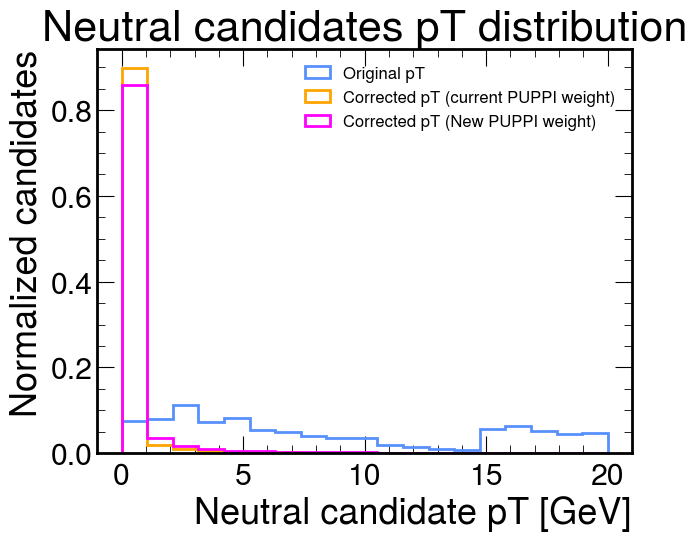

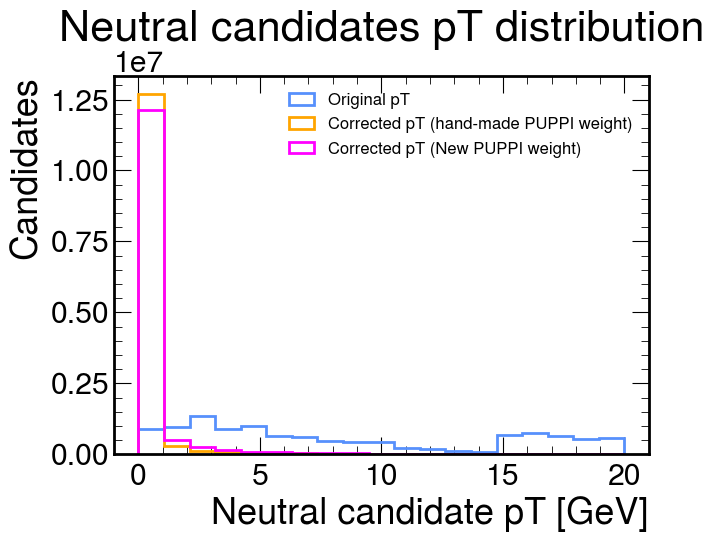

In [114]:


genPtSum  = arrays[target_numerator]
recoPtSum = arrays[target_denominator]


# -------------------------
# Compute *new* PUPPI weight
# -------------------------
new_weight = genPtSum / (recoPtSum + 1e-6)

# Convert to awkward
akpt          = pt
akcharge      = charge
ak_old_weight = weight
ak_new_weight = new_weight

# -------------------------
# MASK FOR NEUTRAL CANDIDATES ONLY
# -------------------------
neutral_mask = (akcharge == 0)

pt_neutral        = akpt[neutral_mask]
old_weight_neutral = ak_old_weight[neutral_mask]
new_weight_neutral = ak_new_weight[neutral_mask]

# Corrected pTs
pt_corr_old = pt_neutral * old_weight_neutral
pt_corr_new = pt_neutral * new_weight_neutral

# -------------------------
# Flatten safely
# -------------------------
flat_pt        = ak.flatten(pt_neutral, axis=None).to_numpy()
flat_pt_old    = ak.flatten(pt_corr_old, axis=None).to_numpy()
flat_pt_new    = ak.flatten(pt_corr_new, axis=None).to_numpy()

# Remove non-finite
flat_pt        = flat_pt[np.isfinite(flat_pt)]
flat_pt_old    = flat_pt_old[np.isfinite(flat_pt_old)]
flat_pt_new    = flat_pt_new[np.isfinite(flat_pt_new)]

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(7,6))
bins = np.linspace(0, 20, 20)

plt.hist(flat_pt, bins=bins, histtype="step", linewidth=2, density=True,
         label="Original pT ")
plt.hist(flat_pt_old, bins=bins, histtype="step", linewidth=2, density=True,color='orange',
         label="Corrected pT (current PUPPI weight)")
plt.hist(flat_pt_new, bins=bins, histtype="step", linewidth=2, density=True,color='magenta',
         label="Corrected pT (New PUPPI weight)")

plt.xlabel("Neutral candidate pT [GeV]")
plt.ylabel("Normalized candidates")
plt.legend(fontsize=12)
plt.title("Neutral candidates pT distribution")

plt.grid(False)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7,6))
bins = np.linspace(0, 20, 20)

plt.hist(flat_pt, bins=bins, histtype="step", linewidth=2, density=False,
         label="Original pT ")
plt.hist(flat_pt_old, bins=bins, histtype="step", linewidth=2, density=False,color='orange',
         label="Corrected pT (hand-made PUPPI weight)")
plt.hist(flat_pt_new, bins=bins, histtype="step", linewidth=2, density=False,color='magenta',
         label="Corrected pT (New PUPPI weight)")

plt.xlabel("Neutral candidate pT [GeV]")
plt.ylabel("Candidates")
plt.legend(fontsize=12)
plt.title("Neutral candidates pT distribution")

plt.grid(False)
plt.tight_layout()
plt.show()


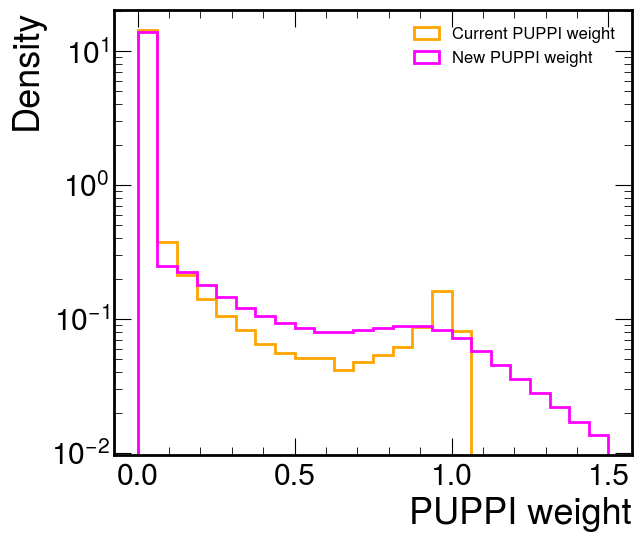

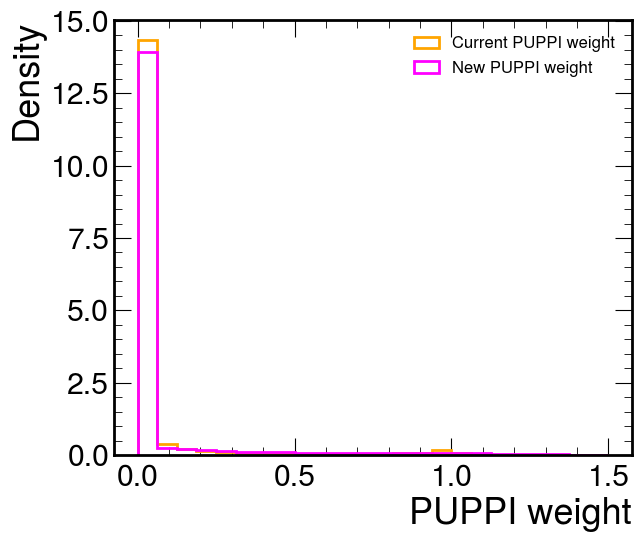

In [115]:
# Plot the distribution of the new weight

ak_old_w = ak.Array(weight)
ak_new_w = ak.Array(new_weight)
ak_charge = ak.Array(charge)

neutral_mask = (ak_charge == 0)

old_w_neu = ak_old_w[neutral_mask]
new_w_neu = ak_new_w[neutral_mask]
flat_old_w     = ak.flatten(old_w_neu, axis=None).to_numpy()
flat_new_w     = ak.flatten(new_w_neu, axis=None).to_numpy()

plt.figure(figsize=(7,6))
bins = np.linspace(0, 1.5, 25)

plt.hist(flat_old_w, bins=bins, histtype="step", linewidth=2, density=True, color='orange',
         label="Current PUPPI weight")
plt.hist(flat_new_w, bins=bins, histtype="step", linewidth=2, density=True, color='magenta',
         label="New PUPPI weight")

plt.xlabel("PUPPI weight")
plt.ylabel("Density")
plt.yscale("log")
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
bins = np.linspace(0, 1.5, 25)

plt.hist(flat_old_w, bins=bins, histtype="step", linewidth=2, density=True, color='orange',
         label="Current PUPPI weight")
plt.hist(flat_new_w, bins=bins, histtype="step", linewidth=2, density=True, color='magenta',
         label="New PUPPI weight")

plt.xlabel("PUPPI weight")
plt.ylabel("Density")
plt.legend(fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()


In [116]:
# create the new branches for the hand-made PUPPI collection, which will be used later for the jet resolution

new_selected_counts = []
new_selected_pts = []     # list of lists
new_selected_etas = []
new_selected_phis = []
new_selected_masses = []
new_selected_effective_pts = []  # pt after weighting (for MET)

for iev in range(len(pt)):

    sel_pt = []
    sel_eta = []
    sel_phi = []
    sel_mass = []
    sel_effpt = []   # pt used in MET (pt*weight or pt)
    if iev % 5000 == 0:
        print(f"Processing event {iev}/{len(pt)}")
    for pt_i, weight_i, charge_i, nnVtxScore_i, eta_i, phi_i, mass_i, pdgid_i in zip(
            pt[iev], new_weight[iev], charge[iev], nnVtxScore[iev],
            eta[iev], phi[iev], mass[iev], pdgid[iev]):

        abs_eta = abs(eta_i)

        ###############
        # Barrel
        ###############

        if abs_eta < 1.5:
        
            if charge_i == 0:
                #print(f"Event {iev}: Neutral candidate with pt={pt_i}, eta = {eta_i}, reweighter pt = {pt_i * weight_i}, phi = {phi_i}, weight={weight_i}")
                if np.round((pt_i * weight_i) / 0.25) * 0.25 >= 1:
                    eff_pt = pt_i * weight_i
                    eff_pt = np.round(eff_pt / 0.25) * 0.25
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")

            if charge_i !=0:
                if nnVtxScore_i > 0.1:
                    eff_pt = pt_i
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)

        ###############
        # HGCAL with TK
        ###############
        if 1.5 < abs_eta < 2.5:

            if charge_i == 0:
                if abs_eta < 2.0:
                    pt_cut = 1.0
                else:
                    pt_cut = 2.0
                
                if np.round((pt_i * weight_i) / 0.25) * 0.25 >= pt_cut:
                    eff_pt = pt_i * weight_i
                    eff_pt = np.round(eff_pt / 0.25) * 0.25
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")

            if charge_i !=0:
                if nnVtxScore_i >= 0.1:
                    eff_pt = pt_i
                    sel_pt.append(pt_i)
                    sel_eta.append(eta_i)
                    sel_phi.append(phi_i)
                    sel_mass.append(mass_i)
                    sel_effpt.append(eff_pt)
                    #if iev == 82:
                    #    print(f"YESSSS: Selected PUPPI candidate with pt={eff_pt}, eta={eta_i}, phi={phi_i}, weight={weight_i}, original pt={pt_i}")
        ###############
        # HGCAL no-TK
        ###############

        elif 2.5 < abs_eta < 3.0:
            continue  # your original code skipped them

        ###############
        # HF
        ###############
        elif 3.0 < abs_eta < 5.2:
            continue  # skipped in your code
    # store per-event results to compute the MET later

    new_selected_counts.append(len(sel_effpt))     # same as before, but using final selected
    new_selected_pts.append(sel_pt)
    new_selected_etas.append(sel_eta)
    new_selected_phis.append(sel_phi)
    new_selected_masses.append(sel_mass)
    new_selected_effective_pts.append(sel_effpt)

Processing event 0/50000
Processing event 5000/50000
Processing event 10000/50000
Processing event 15000/50000
Processing event 20000/50000
Processing event 25000/50000
Processing event 30000/50000
Processing event 35000/50000
Processing event 40000/50000
Processing event 45000/50000


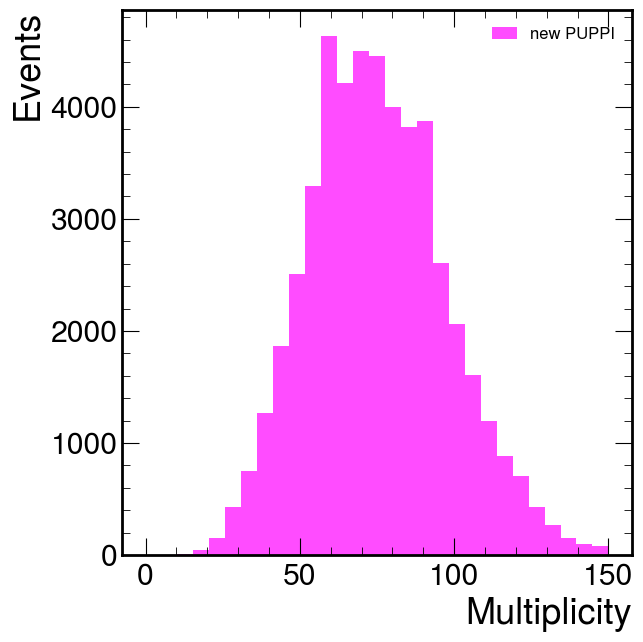

In [117]:
# Plot new PUPPI collection
plt.figure(figsize=(7,7))

bins = np.linspace(0, 150, 30)  # 10 bins from 0 to 30
plt.hist(new_selected_counts, bins=bins, alpha=0.7, color='magenta', label='new PUPPI')
plt.xlabel('Multiplicity')
plt.ylabel('Events')
plt.legend(fontsize=12)


plt.tight_layout()
plt.show()

## Recluster Jets with hand-made PUPPI collection

We use hand-made PUPPI collection (from puppi_as_pf root file), and compare the reclustered jets with the scPUPPIJets


In [118]:
N = 50000  # only process 50000 events

# Build full hand-made particles
particles_handmade_all = ak.zip({
    "pt":  ak.Array(selected_effective_pts),
    "eta": ak.Array(selected_etas),
    "phi": ak.Array(selected_phis),
})

# Use only first N events for both collections
particles_handmade = particles_handmade_all[:N]


newJets_handmade  = seeded_cone_exact(particles_handmade, R=0.4, max_jets=16)


100%|██████████| 50000/50000 [00:57<00:00, 873.50it/s] 


## Recluster Jets with new PUPPI collection (with new Target!)

We use the new PUPPI collection, made with the new target, so recluster Jets and compare them with PuppiJets

In [119]:
N = 50000  # only process 50000 events

# Build full hand-made particles
particles_new_all = ak.zip({
    "pt":  ak.Array(new_selected_effective_pts),
    "eta": ak.Array(new_selected_etas),
    "phi": ak.Array(new_selected_phis),
})

# Use only first N events for both collections
particles_new = particles_new_all[:N]


newJets_new  = seeded_cone_exact(particles_new, R=0.4, max_jets=16)


100%|██████████| 50000/50000 [00:54<00:00, 913.25it/s] 


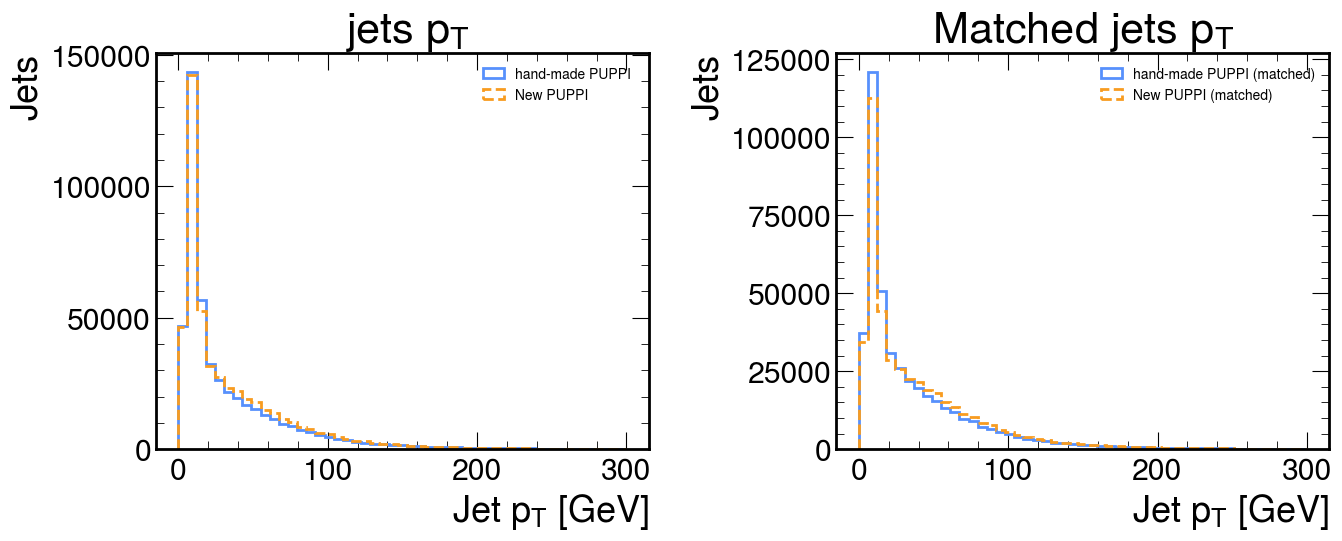

In [120]:
## Match the 2 jets collection : hand-made PUPPI has already been demonstrated to be same to original PUPPi colelction
matches_two_puppi  = match_jets(newJets_new, newJets_handmade, dR_max=0.4)
res_two_puppi      = compute_residuals(matches_two_puppi)

# Get matched jets
j1m = ak.drop_none(matches_two_puppi["j1"])  # new PUPPI
j2m = ak.drop_none(matches_two_puppi["j2"])  # hand-made PUPPI

# Non matched jets (for reference)
j1 = ak.drop_none(newJets_new)  # new PUPPI
j2 = ak.drop_none(newJets_handmade)  # hand-made PUPPI

pt_new_matched_hm = ak.to_numpy(ak.flatten(j1m.pt, axis=None))
pt_ref_matched_hm = ak.to_numpy(ak.flatten(j2m.pt, axis=None))

pt_new = ak.to_numpy(ak.flatten(j1.pt, axis=None))
pt_ref = ak.to_numpy(ak.flatten(j2.pt, axis=None))


bins_match = np.linspace(0, 300, 50)

# --- Side-by-side plots ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: matched new vs matched ref
axs[0].hist(pt_ref, bins=bins_match, histtype="step", linewidth=2,
            label="hand-made PUPPI ")
axs[0].hist(pt_new, bins=bins_match, histtype="step", linewidth=2, linestyle="--",
            label="New PUPPI")
axs[0].set_xlabel(r"Jet $p_T$ [GeV]")
axs[0].set_ylabel("Jets")
axs[0].set_title(" jets $p_T$")
axs[0].legend(fontsize=10)

axs[1].hist(pt_ref_matched_hm, bins=bins_match, histtype="step", linewidth=2,
            label="hand-made PUPPI (matched)")
axs[1].hist(pt_new_matched_hm, bins=bins_match, histtype="step", linewidth=2, linestyle="--",
            label="New PUPPI (matched)")
axs[1].set_xlabel(r"Jet $p_T$ [GeV]")
axs[1].set_ylabel("Jets")
axs[1].set_title("Matched jets $p_T$")
axs[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

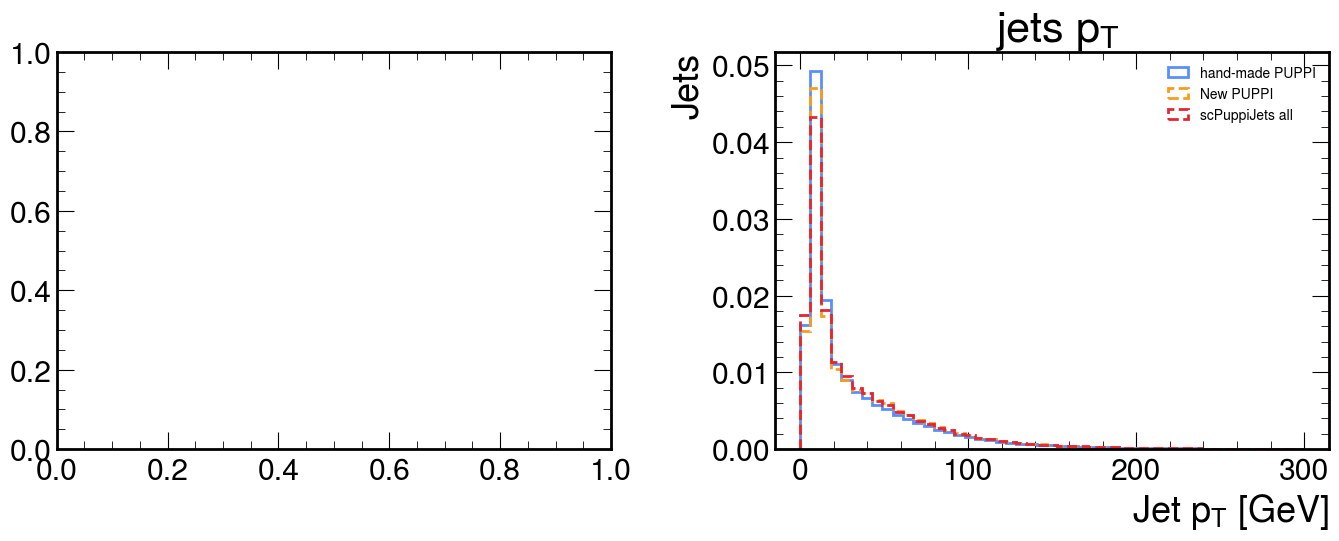

In [121]:

bins_match = np.linspace(0, 300, 50)

# --- Side-by-side plots ---
fig, axs = plt.subplots(1, 2, figsize=(14, 6))



axs[1].hist(pt_ref, bins=bins_match, histtype="step", linewidth=2, density=True,
            label="hand-made PUPPI")
axs[1].hist(pt_new, bins=bins_match, histtype="step", linewidth=2, linestyle="--", density=True,
            label="New PUPPI ")
axs[1].hist(pt_ref_all, bins=bins_match, histtype="step", linewidth=2, linestyle="--", density=True,
            label="scPuppiJets all")
axs[1].set_xlabel(r"Jet $p_T$ [GeV]")
axs[1].set_ylabel("Jets")
axs[1].set_title(" jets $p_T$")
axs[1].legend(fontsize=10)
plt.tight_layout()
plt.show()

[]

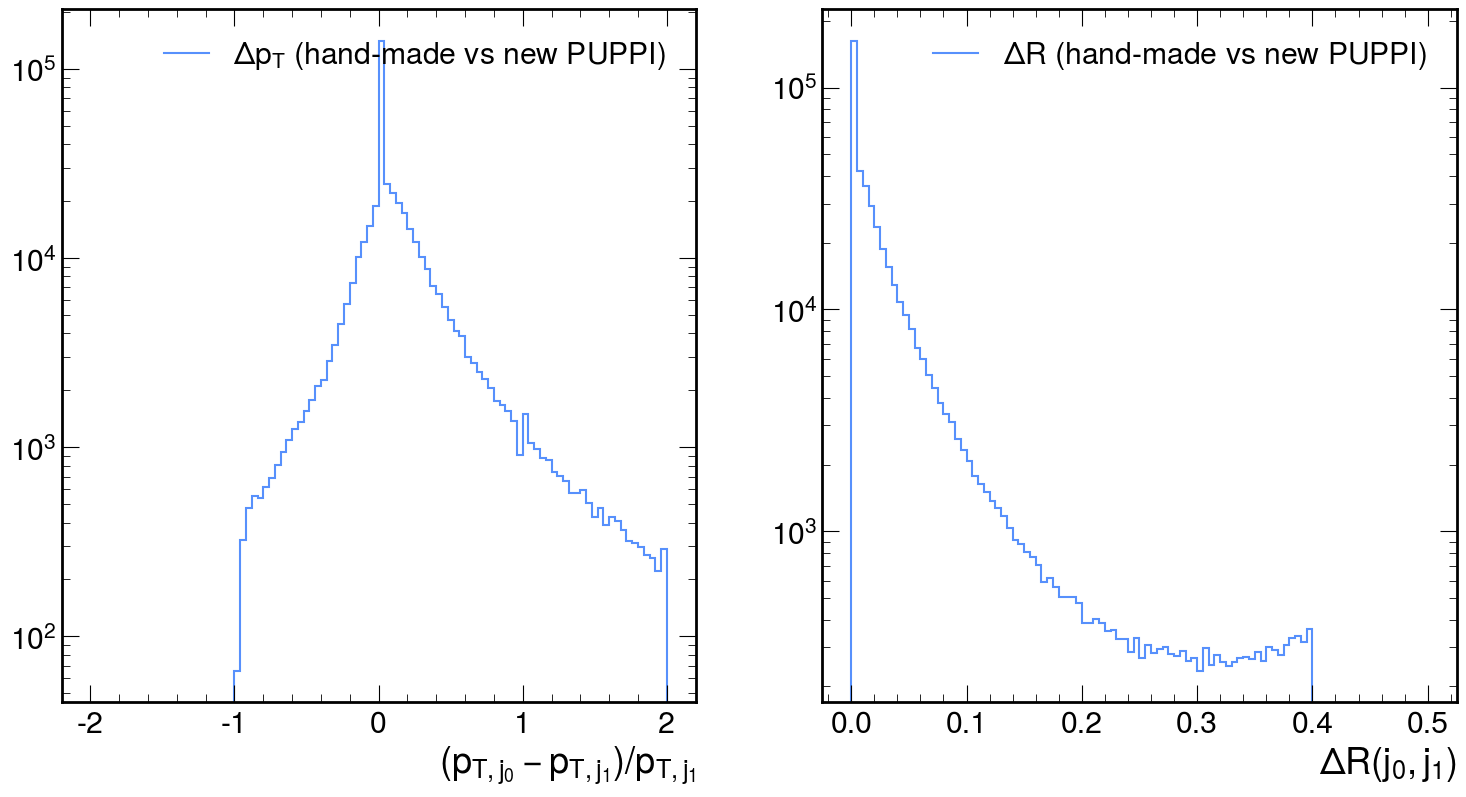

In [122]:
pt_bins = np.linspace(-2, 2, 101)
dR_bins = np.linspace(0, 0.5, 101)

f, axs = plt.subplots(1, 2, figsize=(18, 9))

h, _ = np.histogram(res_two_puppi["pt"], bins=pt_bins)
hep.histplot(h, pt_bins, label=r"$\Delta p_T$ (hand-made vs new PUPPI)", ax=axs[0])

h, _ = np.histogram(res_two_puppi["deltaR"], bins=dR_bins)
hep.histplot(h, dR_bins, label=r"$\Delta R$ (hand-made vs new PUPPI)", ax=axs[1])

axs[0].set_xlabel(r"$(p_{T, j_0} - p_{T, j_1}) / p_{T, j_1}$")
axs[1].set_xlabel(r"$\Delta R (j_0, j_1)$")
axs[0].legend()
axs[1].legend()
axs[0].semilogy()
axs[1].semilogy()

In [123]:
gen_jets_new = vector.zip({
    "pt":  arrays["GenJets_pt"],
    "eta": arrays["GenJets_eta"],
    "phi": arrays["GenJets_phi"],
})
## Matched and non matched jets! It should be ok and same in this case

# Match reclustered jets to GEN jets
matches_gen_newpuppi = match_jets(newJets_new, gen_jets_new, dR_max=0.4)
res_gen_newpuppi = compute_residuals(matches_gen_newpuppi)

print(f"Matched {len(res_gen_newpuppi['pt'])} reclustered jets to GEN jets")

# Match scPuppiJets to GEN jets
matches_gen_handmade = match_jets(newJets_handmade, gen_jets_new, dR_max=0.4)
res_gen_handmade = compute_residuals(matches_gen_handmade)

print(f"Matched {len(res_gen_handmade['pt'])} scPuppiJets to GEN jets")

# Define pT bins for analysis (same as used in reco vs ref comparison)
pt_bins = np.array([0, 20, 40, 60, 80, 100, 150, 200])
pt_bin_centers = 0.5 * (pt_bins[:-1] + pt_bins[1:])


# --- Apply eta cut ---
#eta_cut = 1.3
#matches_gen_newpuppi = matches_gen_newpuppi[abs(matches_gen_newpuppi.j2.eta) < eta_cut]
#matches_gen_handmade = matches_gen_handmade[abs(matches_gen_handmade.j2.eta) < eta_cut]

print(f"pT bins: {pt_bins}")
print(f"pT bin centers: {pt_bin_centers}")

Matched 301418 reclustered jets to GEN jets
Matched 278057 scPuppiJets to GEN jets
pT bins: [  0  20  40  60  80 100 150 200]
pT bin centers: [ 10.  30.  50.  70.  90. 125. 175.]


In [124]:


# Extract matched jets
j1_gen_newpuppi = ak.drop_none(matches_gen_newpuppi["j1"])  # reclustered jets
j2_gen_newpuppi = ak.drop_none(matches_gen_newpuppi["j2"])  # GEN jets

pt_gen_newpuppi = ak.to_numpy(ak.flatten(j2_gen_newpuppi.pt, axis=None))    # GEN jet pT (x-axis)
pt_reco_newpuppi = ak.to_numpy(ak.flatten(j1_gen_newpuppi.pt, axis=None))   # reclustered jet pT

# Compute resolution and response
response_ratio_gen_newpuppi = pt_reco_newpuppi / pt_gen_newpuppi                      # response

# Bin the data
bin_indices_gen_newpuppi = np.digitize(pt_gen_newpuppi, pt_bins) - 1

# Compute mean, RMS (std), and error on mean in each bin
median_response_gen_newpuppi = []
err_median_response_gen_newpuppi = []  # Error on the median (using bootstrapping or approximation)
std_reco_newpuppi = []
pt_reco_median_newpuppi = []

for i in range(len(pt_bins) - 1):
    mask = bin_indices_gen_newpuppi == i
    if not np.any(mask):

        median_response_gen_newpuppi.append(np.nan)
        err_median_response_gen_newpuppi.append(np.nan)
        std_reco_newpuppi.append(np.nan)
        pt_reco_median_newpuppi.append(np.nan)
        continue
    
    vals_resp = response_ratio_gen_newpuppi[mask]
    N = len(vals_resp)


    median_response_gen_newpuppi.append(np.median(vals_resp))
    std_resp_newpuppi = np.std(vals_resp)
    err_median_response_gen_newpuppi.append(std_resp / np.sqrt(N))  # Standard error of the median
    std_reco_newpuppi.append(np.std(pt_reco_newpuppi[mask]))
    pt_reco_median_newpuppi.append(np.median(pt_reco_newpuppi[mask]))

median_response_gen_newpuppi = np.array(median_response_gen_newpuppi)
err_median_response_gen_newpuppi = np.array(err_median_response_gen_newpuppi)
std_reco_newpuppi = np.array(std_reco_newpuppi)
pt_reco_median_newpuppi= np.array(pt_reco_median_newpuppi)

print("Reclustered vs GEN statistics computed")

Reclustered vs GEN statistics computed


In [125]:

# Extract matched jets
j1_gen_handmade = ak.drop_none(matches_gen_handmade["j1"])  # scPuppiJets
j2_gen_handmade = ak.drop_none(matches_gen_handmade["j2"])  # GEN jets

pt_gen_handmade = ak.to_numpy(ak.flatten(j2_gen_handmade.pt, axis=None))      # GEN jet pT
pt_handmade = ak.to_numpy(ak.flatten(j1_gen_handmade.pt, axis=None))          # scPuppi jet pT

# Compute resolution and response
response_ratio_handmade_gen = pt_handmade / pt_gen_handmade                # response

# Bin the data
bin_indices_handmade_gen = np.digitize(pt_gen_handmade, pt_bins) - 1

# Compute mean, RMS (std), and error on mean in each bin

median_response_handmade_gen = []
err_median_response_handmade_gen = []  # Error on the median (using bootstrapping or approximation)
std_reco_handmade = []
pt_reco_median_handmade = []

for i in range(len(pt_bins) - 1):
    mask = bin_indices_handmade_gen == i
    if not np.any(mask):

        median_response_handmade_gen.append(np.nan)
        err_median_response_handmade_gen.append(np.nan)
        std_reco_handmade.append(np.nan)
        pt_reco_median_handmade.append(np.nan)
        std_reco_handmade.append(np.nan)
        pt_reco_median_handmade.append(np.nan)
        continue
    
    vals_resp = response_ratio_handmade_gen[mask]
    N = len(vals_resp)
    

    median_response_handmade_gen.append(np.median(vals_resp))
    std_resp = np.std(vals_resp)
    err_median_response_handmade_gen.append(std_resp / np.sqrt(N))  # Standard error of the median
    std_reco_handmade.append(np.std(pt_handmade[mask]))
    pt_reco_median_handmade.append(np.median(pt_handmade[mask]))


median_response_handmade_gen = np.array(median_response_handmade_gen)
err_median_response_handmade_gen = np.array(err_median_response_handmade_gen)
std_reco_handmade = np.array(std_reco_handmade)
pt_reco_median_handmade = np.array(pt_reco_median_handmade)

print("scPuppiJets vs GEN statistics computed")

scPuppiJets vs GEN statistics computed


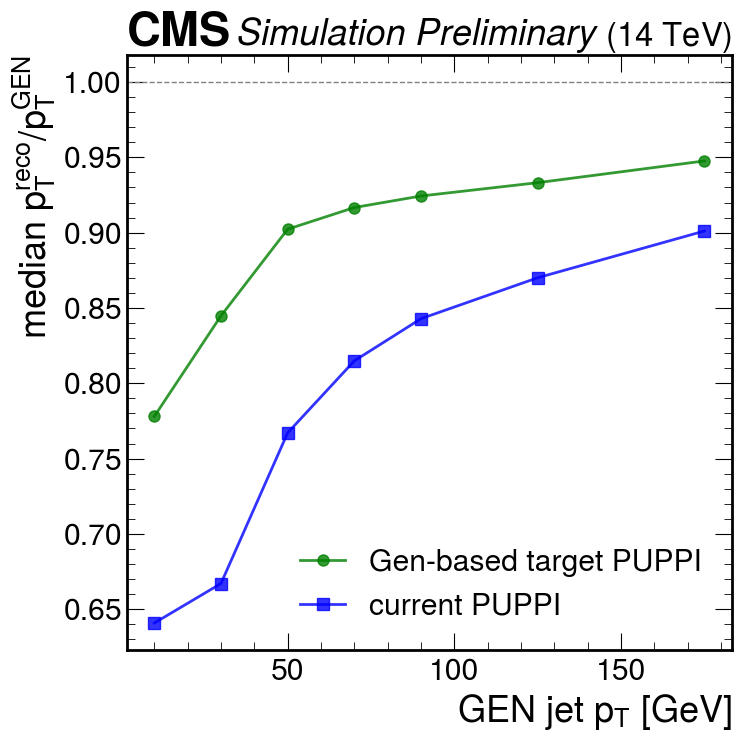

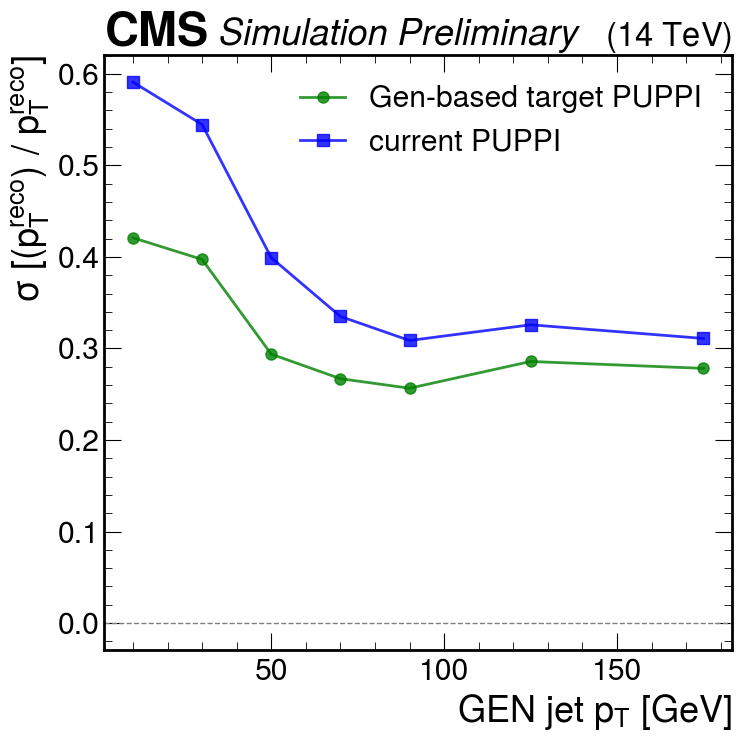

In [126]:

# --- Comparison: Reclustered vs scPuppiJets (both against GEN) ---
import mplhep as hep
hep.style.use("CMS") 
# --- Comparison: Reclustered vs scPuppiJets (both against GEN) ---

# Canvas 1: Response comparison
fig1, ax1 = plt.subplots(figsize=(8, 8))

ax1.plot(pt_bin_centers, median_response_gen_newpuppi, "o-", color="green", linewidth=2, markersize=8,
         label="Gen-based target PUPPI", alpha=0.8)
ax1.plot(pt_bin_centers, median_response_handmade_gen, "s-", color="blue", linewidth=2, markersize=8,
         label="current PUPPI", alpha=0.8)
ax1.axhline(1.0, color="gray", linestyle="--", linewidth=1)
ax1.set_xlabel(r"GEN jet $p_T$ [GeV]")
ax1.set_ylabel(r"median $p_T^\mathrm{reco} / p_T^\mathrm{GEN}$")
ax1.set_title(" ")

hep.cms.label("Preliminary", data=False, com=14, loc=0)
ax1.legend()
plt.tight_layout()
plt.show()

# Canvas 2: Resolution comparison
fig2, ax2 = plt.subplots(figsize=(8, 8))

ax2.plot(pt_bin_centers, std_reco_newpuppi / pt_reco_median_newpuppi, "o-", color="green", linewidth=2, markersize=8,
         label="Gen-based target PUPPI", alpha=0.8)
ax2.plot(pt_bin_centers, std_reco_handmade / pt_reco_median_handmade, "s-", color="blue", linewidth=2, markersize=8,
         label="current PUPPI", alpha=0.8)
ax2.axhline(0.0, color="gray", linestyle="--", linewidth=1)
ax2.set_xlabel(r"GEN jet $p_T$ [GeV]")
ax2.set_ylabel(r"$\sigma$ [($p_T^\mathrm{reco}$) / $p_T^\mathrm{reco}$]")
ax2.set_title(" ")

hep.cms.label("Preliminary", data=False, com=14, loc=0)
ax2.legend()
plt.tight_layout()
plt.show()


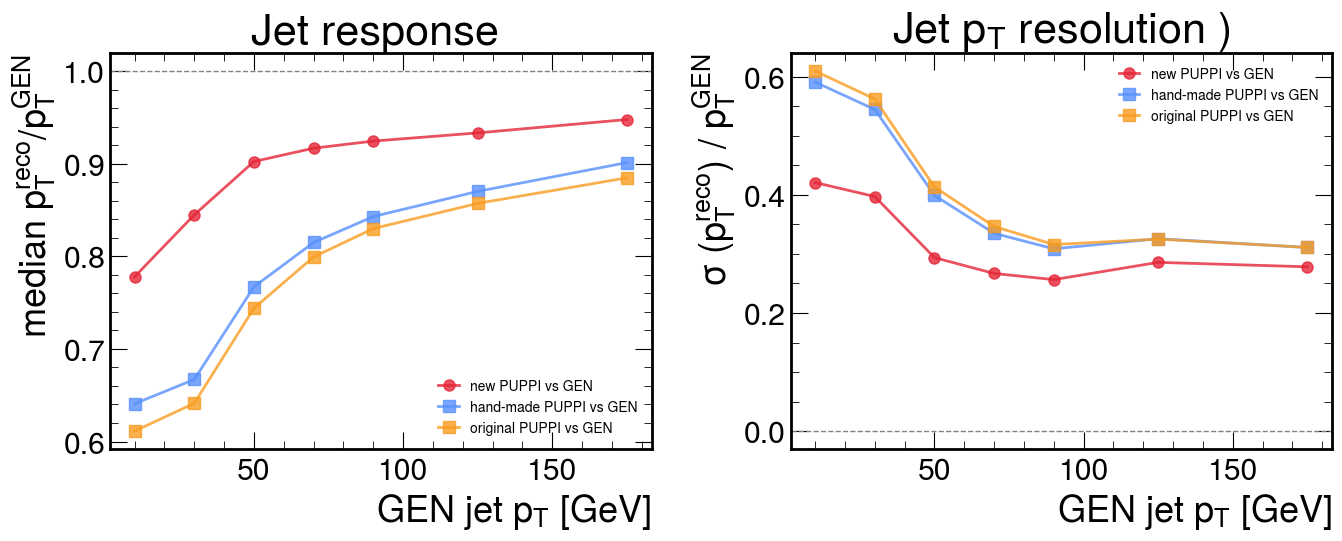

In [127]:
# --- Comparison: Reclustered vs scPuppiJets (both against GEN) ---

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: Response comparison (using error on the mean, not RMS!)
axs[0].plot(pt_bin_centers, median_response_gen_newpuppi, "o-", color="C2", linewidth=2, markersize=8,
            label="new PUPPI vs GEN", alpha=0.8)
axs[0].plot(pt_bin_centers, median_response_handmade_gen, "s-", color="C0", linewidth=2, markersize=8,
            label="hand-made PUPPI vs GEN", alpha=0.8)
axs[0].plot(pt_bin_centers, median_response_gen, "s-", color="C1", linewidth=2, markersize=8,
            label="original PUPPI vs GEN", alpha=0.8)
axs[0].axhline(1.0, color="gray", linestyle="--", linewidth=1)
axs[0].set_xlabel(r"GEN jet $p_T$ [GeV]")
axs[0].set_ylabel(r"median $p_T^\mathrm{reco} / p_T^\mathrm{GEN}$")
axs[0].set_title("Jet response ")
axs[0].legend(fontsize=10)
#axs[0].grid(True, alpha=0.3)

# Right: Resolution σ comparison
axs[1].plot(pt_bin_centers, std_reco_newpuppi/pt_reco_median_newpuppi, "o-", color="C2", linewidth=2, markersize=8,
            label="new PUPPI vs GEN", alpha=0.8)
axs[1].plot(pt_bin_centers, std_reco_handmade/pt_reco_median_handmade, "s-", color="C0", linewidth=2, markersize=8,
            label="hand-made PUPPI vs GEN", alpha=0.8)
axs[1].plot(pt_bin_centers, std_reco/pt_reco_median, "s-", color="C1", linewidth=2, markersize=8,
            label="original PUPPI vs GEN", alpha=0.8)
axs[1].axhline(0.0, color="gray", linestyle="--", linewidth=1)
axs[1].set_xlabel(r"GEN jet $p_T$ [GeV]")
axs[1].set_ylabel(r"$\sigma$ ($p_T^\mathrm{reco}$) / $p_T^\mathrm{GEN}$")
axs[1].set_title("Jet $p_T$ resolution )")
axs[1].legend(fontsize=10)
#axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

------

## Example

Example based on a `perfNano.root` ntuple from FastPuppi, with a `L1PuppiCands` collection (which is made similar to a `L1PFCands` by removing cuts after application of the PUPPI weights) and a `scPuppiJets` collection. 

Different collections could be used for either the particles or reference jets, as long as they have `(pt, eta, phi)` fields.

In [105]:
with uproot.open("/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU200/FP/151Xv0/perfNano_16676705_126.root") as file:
    tree = file["Events"]
    particles = ak.zip({
        "pt": tree["L1PuppiCands_pt"].array(),
        "eta": tree["L1PuppiCands_eta"].array(),
        "phi": tree["L1PuppiCands_phi"].array()
    })
    ref_jets = vector.zip({
        "pt": tree["scPuppiJets_pt"].array(),
        "eta": tree["scPuppiJets_eta"].array(),
        "phi": tree["scPuppiJets_phi"].array()
    })
   
    newJets_sc = seeded_cone_exact(particles, R=0.4, max_jets=12)



FileNotFoundError: [Errno 2] No such file or directory: '/eos/cms/store/cmst3/group/l1tr/elfontan/l1tPFplusPuppi/fp_ntuples_151X_targetStudies/TT_PU200/FP/151Xv0/perfNano_16676705_126.root'

## Evaluate

First perform matching and plot the residuals

In [6]:
matches_py_ref = match_jets(newJets_sc, ref_jets, dR_max=0.4)

res_py_ref = compute_residuals(matches_py_ref)

[]

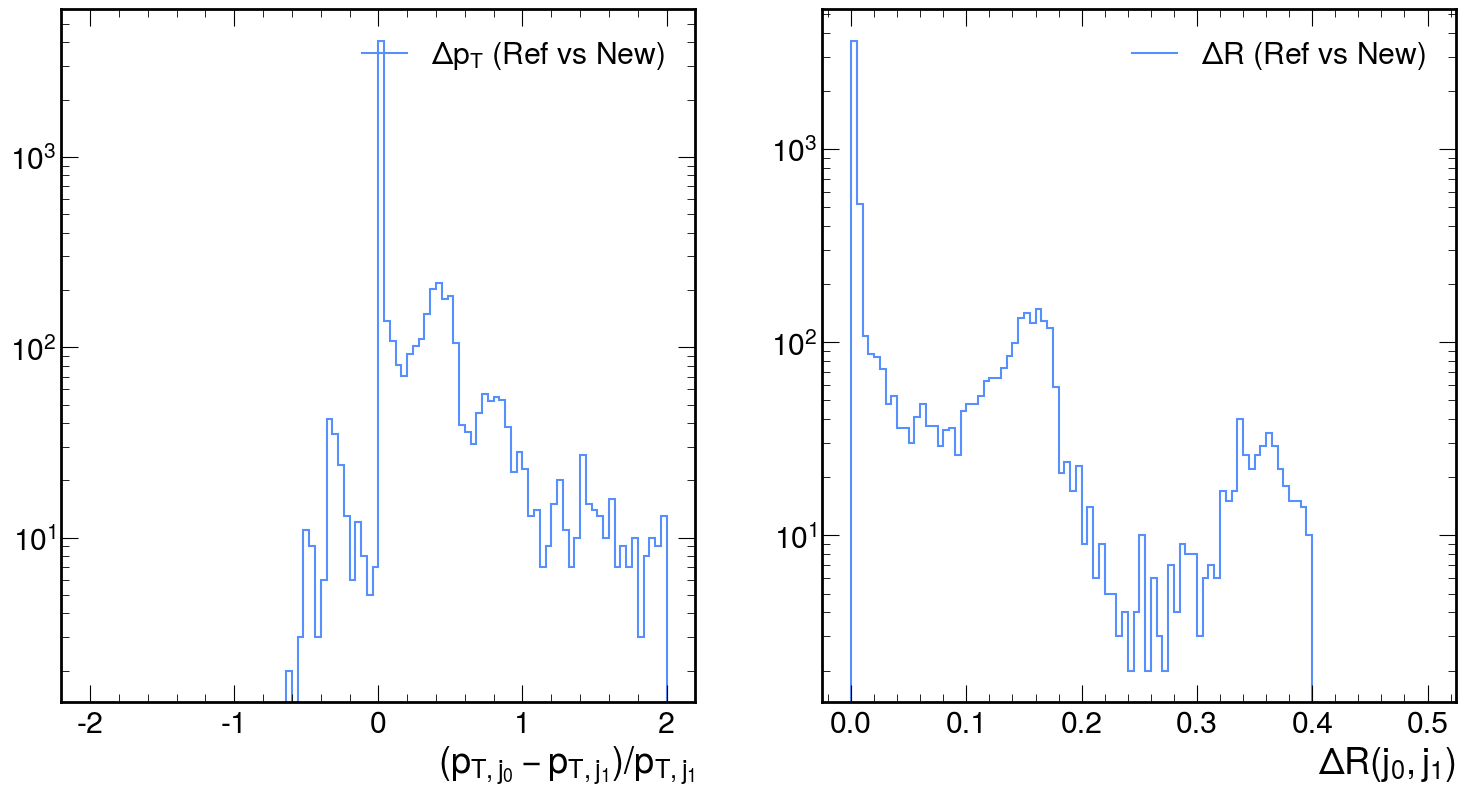

In [7]:
pt_bins = np.linspace(-2, 2, 101)
dR_bins = np.linspace(0, 0.5, 101)
f, axs = plt.subplots(1, 2, figsize=(18, 9))

h, _ = np.histogram(res_py_ref['pt'], bins=pt_bins)
hep.histplot(h, pt_bins, label=r'$\Delta p_T$ (Ref vs New)', ax=axs[0])
    
h, _ = np.histogram(res_py_ref['deltaR'], bins=dR_bins)
hep.histplot(h, dR_bins, label=r'$\Delta R$ (Ref vs New)', ax=axs[1])
    
axs[0].set_xlabel(r'($p_{T, j_0} - p_{T, j_1}) / p_{T, j_1}$')
axs[1].set_xlabel(r'$\Delta R (j_0, j_1)$')
axs[0].legend()
axs[1].legend()
axs[0].semilogy()
axs[1].semilogy()

## Event display

For some extra visual validation, make an event display of the two jet collections and the constituents.

The `event_display` function makes an η–φ plot for one event:

- draws circles of radius R around jet axes (CMSSW vs Python)
- scatters constituents of each Python jet (size ~ pT)
- scatters leftover unclustered particles in gray
- handles φ wrap-around by drawing a second circle when close to ±π

In [8]:
def event_display(particles, jets_ref, jets_new, R=0.4, event_idx=0):
    """
    Plot an event display of the jets and constituents for some visual validation
    particles: awkward Array with fields (pt, eta, phi)
    jets_ref: vector.Array (jets from exact algorithm)
    jets_new: vector.Array (jets with new PUPPI weights)
    event_idx: which event to plot
    """

    # Get event-level data
    p_eta = ak.to_numpy(particles[event_idx].eta)
    p_phi = ak.to_numpy(particles[event_idx].phi)
    p_pt  = ak.to_numpy(particles[event_idx].pt)

    j_eta_ref = ak.to_numpy(jets_ref[event_idx].eta)
    j_phi_ref = ak.to_numpy(jets_ref[event_idx].phi)

    j_eta_new = ak.to_numpy(jets_new[event_idx].eta)
    j_phi_new = ak.to_numpy(jets_new[event_idx].phi)

    fig, ax = plt.subplots(figsize=(7,6))

    def add_circle(e, p, R, edgecolor, linestyle, label):
        circ = mpatches.Circle((e, p), radius=R, fill=False, linestyle=linestyle,
                               edgecolor=edgecolor, linewidth=2, alpha=0.8, label=label)
        ax.add_patch(circ)        
        # add another circle at the pi boundary if close to the edge
        if (np.pi - np.abs(p)) < 0.4:
            p_wrap = p - 2 * np.pi if p > 0 else p + 2 * np.pi
            circ = mpatches.Circle((e, p_wrap), radius=R, fill=False, linestyle=linestyle,
                                   edgecolor=edgecolor, linewidth=2, alpha=0.8, label=label)
            ax.add_patch(circ)  
    
    # REF seeded-cone jets as open circles
    for e, p in zip(j_eta_ref, j_phi_ref):
        add_circle(e, p, R, "C0", "-", "Ref (scPuppiJets)")
        #add_circle(e, p, R, "C0", "-", "CMSSW jet")
 
    # NEW seeded-cone jets as open circles
    for e, p in zip(j_eta_new, j_phi_new):
        add_circle(e, p, R, "C1", "--", "New PUPPI jets")
        #add_circle(e, p, R, "C1", "--", "Py jet")

    # Jet constituents as points
    for j, _ in enumerate(jets_new[event_idx]):
        constituent_idxs = jets_new[event_idx][j].constituents
        constituents = particles[event_idx][constituent_idxs]
        # size is pT * 3 : a fudge factor to make them reasonably sized
        ax.scatter(constituents.eta, constituents.phi,
                   s=constituents.pt * 3, alpha=0.3, color=f"C{j%10}")
        
    # Unclustered particles as points
    # get the indices of any particles not included in a jet
    # jets constituents are expected to be exclusive
    unclustered_idx = list(set(list(range(len(particles[event_idx])))) - set(ak.ravel(jets_new[event_idx].constituents)))
    unclustered = particles[event_idx][unclustered_idx]
    ax.scatter(unclustered.eta, unclustered.phi,
               s=unclustered.pt * 3, alpha=0.3, color=f"grey")    
    
    ax.set_xlim((-5, +5))
    ax.set_ylim((-np.pi, np.pi))
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")

    # Deduplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc="best")
    ax.set_aspect('equal')

    plt.show()


len(particles): 2000
len(ref_jets): 2000
len(newJets_sc): 2000


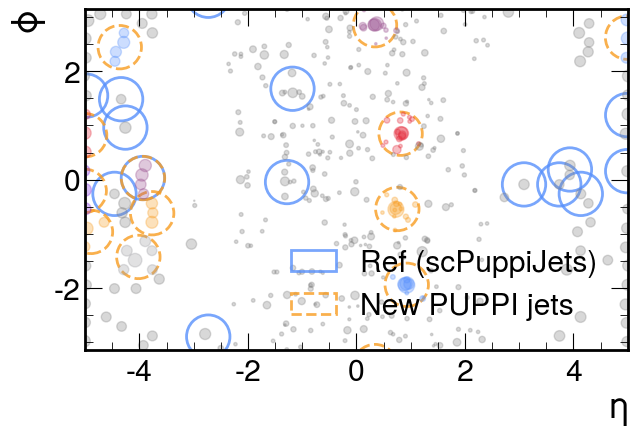

In [9]:
print("len(particles):", len(particles))
print("len(ref_jets):", len(ref_jets))
print("len(newJets_sc):", len(newJets_sc))
#print("type(newJets_sc):", type(newJets_sc))
#print("newJets_sc.type:", newJets_sc.type)

event_display(particles, ref_jets, newJets_sc, event_idx=1)